In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

C:\Users\Abdrh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("amdj3dax/ransomware-detection-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abdrh\.cache\kagglehub\datasets\amdj3dax\ransomware-detection-data-set\versions\1


In [3]:
csv_path = os.path.join(path, "data_file.csv")

df = pd.read_csv(csv_path)
df.head()

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll,79755c51e413ed3c6be4635fd729a6e1,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,05c8318f98a5d301d80000009c316005.vertdll.dll,95e19f3657d34a432eada93221b0ea16,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,06054fba-5619-4a86-a861-ffb0464bef5d.dll,85c32641d77a54e19ba8ea4ab305c791,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,075822ac99a5d301660400009c316005.adhapi.dll,62e3b959d982ef534b66f819fe15f085,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,090607dd9ba5d301ca0900009c316005.SensorsNative...,ae38c5f7d313ad0ff3bfb8826476767f,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-null  int64 
 16  BitcoinAddresses    62

Target Distribution:


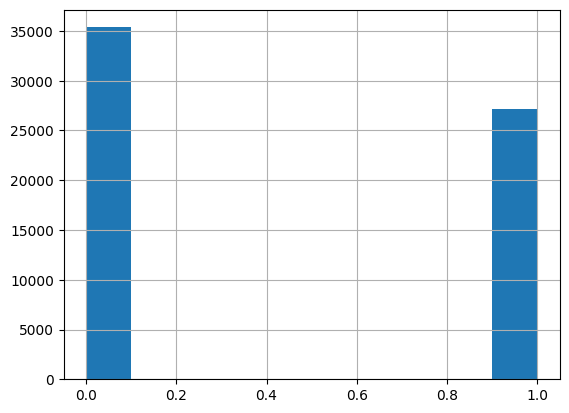

In [5]:
# 1. Is the target imbalanced?
def check_target_imbalance(df, target_column):
  print("Target Distribution:")

  df[target_column].hist()  # Yeah you can just do this :)
  plt.show()

check_target_imbalance(df, "Benign")

In [6]:
# 2. Do we have missing values?
def check_missing_values(df):
  missing_values = df.isnull().sum()
  print("Missing Values per Column:")
  print(missing_values[missing_values > 0])
  if missing_values.any():
    print("\nHandle Missing Values as needed.")
  else:
    print("\nNo Missing Values Found.")

check_missing_values(df)

Missing Values per Column:
Series([], dtype: int64)

No Missing Values Found.


In [7]:
# 3. Do we have categorical columns?
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:", list(categorical_cols))

Categorical Columns: ['FileName', 'md5Hash']


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

df

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0,30173,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,1,36746,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,2,32970,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,3,24750,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,4,42725,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62480,36620,40235,332,0,0,1,4,0,0,4096,6,0,3,1048576,0,23504,0,0
62481,14100,456,332,0,0,7,10,0,0,0,7,0,7,1048576,0,15704,0,0
62482,16462,4190,332,0,0,0,4,0,0,404908,2,50,11,1048576,0,2364,0,0
62483,48705,61626,332,0,0,0,4,14448,70,4096,8,0,4,1048576,0,130296,0,0


In [9]:
# 4. Do we have duplicate samples?
def check_duplicates(df):
  duplicates = df.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df)

Number of Duplicate Samples: 0
No Duplicate Samples Found.


In [10]:
df.describe()

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
count,62485.000000,62485.000000,62485.000000,6.248500e+04,6.248500e+04,62485.000000,62485.000000,6.248500e+04,6.248500e+04,6.248500e+04,62485.000000,62485.000000,62485.000000,6.248500e+04,62485.000000,6.248500e+04,62485.000000,62485.000000
mean,31242.000000,31242.000000,6756.472657,2.587048e+04,1.541611e+05,58.785997,5.417524,8.953186e+05,4.094623e+05,1.466311e+05,9.782604,6.613171,4.751172,8.759830e+05,12966.031400,1.844664e+05,0.018004,0.433992
std,18038.010122,18038.010122,13345.499919,6.461396e+06,1.903142e+06,1114.068244,2.543697,3.779527e+07,2.851820e+07,1.124630e+06,9.047157,16.976465,2.138584,6.288189e+05,15762.725511,1.732625e+07,0.132968,0.495628
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,15621.000000,15621.000000,332.000000,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000e+00,0.000000e+00,4.096000e+03,6.000000,0.000000,3.000000,2.621440e+05,0.000000,1.080000e+03,0.000000,0.000000
50%,31242.000000,31242.000000,332.000000,0.000000e+00,0.000000e+00,0.000000,5.000000,0.000000e+00,0.000000e+00,8.520000e+03,9.000000,0.000000,5.000000,1.048576e+06,320.000000,2.496000e+03,0.000000,0.000000
75%,46863.000000,46863.000000,332.000000,2.800000e+01,1.283200e+04,6.000000,6.000000,2.875200e+04,1.040000e+02,6.553600e+04,11.000000,10.000000,6.000000,1.048576e+06,32768.000000,2.350400e+04,0.000000,1.000000
max,62484.000000,62484.000000,43620.000000,1.615155e+09,2.852127e+08,63325.000000,260.000000,2.147484e+09,2.415919e+09,6.615450e+07,255.000000,255.000000,33.000000,1.677722e+07,58632.000000,4.294942e+09,1.000000,1.000000


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


numerical_cols = df.select_dtypes(include=["number"]).columns.drop("Benign")  # DON'T SCALE THE TARGET

sklearn_models = {
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=0.75))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=None
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )
}



In [12]:
X = df.drop("Benign", axis=1).astype(float)
y = df['Benign'].astype(float)

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [14]:
n_splits = 5 # K=5 Folds

# Stratified 5-Fold Cross-Validation, shuffled
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [15]:
# Import models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [16]:
sklearn_models = {
  "Support Vector Machine": SVC(
      kernel='rbf',  # 'linear', 'poly', 'rbf', 'sigmoid'
      C=0.75  # Regularization parameter
  ),
  "Decision Tree": DecisionTreeClassifier(
      max_depth=3  # Maximum depth of tree (prevents overfitting)
  ),
  "Random Forest": RandomForestClassifier(
      n_estimators=320,  # Number of trees
      max_depth=4
  )
}

In [17]:
all_results = {}

for name in sklearn_models:
  all_results[name] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

In [18]:
for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  # 1. Split data
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # 2. Train & Validate sklearn models
  for model_name, model in sklearn_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train) # train
    y_pred = model.predict(X_test) # validate

    # 3. Save metrics for that model in this fold
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    all_results[model_name]['accuracy'].append(accuracy)
    all_results[model_name]['precision'].append(precision)
    all_results[model_name]['recall'].append(recall)
    all_results[model_name]['f1'].append(f1)


Fold 1/5
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...

Fold 2/5
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...

Fold 3/5
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...

Fold 4/5
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...

Fold 5/5
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...


In [19]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  Accuracy:  {np.mean(all_results[model_name]['accuracy']):.4f}")
  print(f"  Precision: {np.mean(all_results[model_name]['precision']):.4f}")
  print(f"  Recall:    {np.mean(all_results[model_name]['recall']):.4f}")
  print(f"  F1-Score:  {np.mean(all_results[model_name]['f1']):.4f}")


Support Vector Machine:
  Accuracy:  0.7859
  Precision: 0.8742
  Recall:    0.5917
  F1-Score:  0.7057

Decision Tree:
  Accuracy:  0.9626
  Precision: 0.9238
  Recall:    0.9960
  F1-Score:  0.9585

Random Forest:
  Accuracy:  0.9942
  Precision: 0.9983
  Recall:    0.9884
  F1-Score:  0.9933


In [20]:
# Calculate the majority class baseline
majority_class = y.value_counts().idxmax()
baseline_pred = [majority_class] * len(y)

# Evaluate the baseline
baseline_accuracy = accuracy_score(y, baseline_pred)
baseline_precision = precision_score(y, baseline_pred, average='weighted', zero_division=0)
baseline_recall = recall_score(y, baseline_pred, average='weighted', zero_division=0)
baseline_f1 = f1_score(y, baseline_pred, average='weighted', zero_division=0)

print(f"Baseline Accuracy (majority class): {baseline_accuracy:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}")


Baseline Accuracy (majority class): 0.5660
Baseline Precision: 0.3204
Baseline Recall: 0.5660
Baseline F1-Score: 0.4091


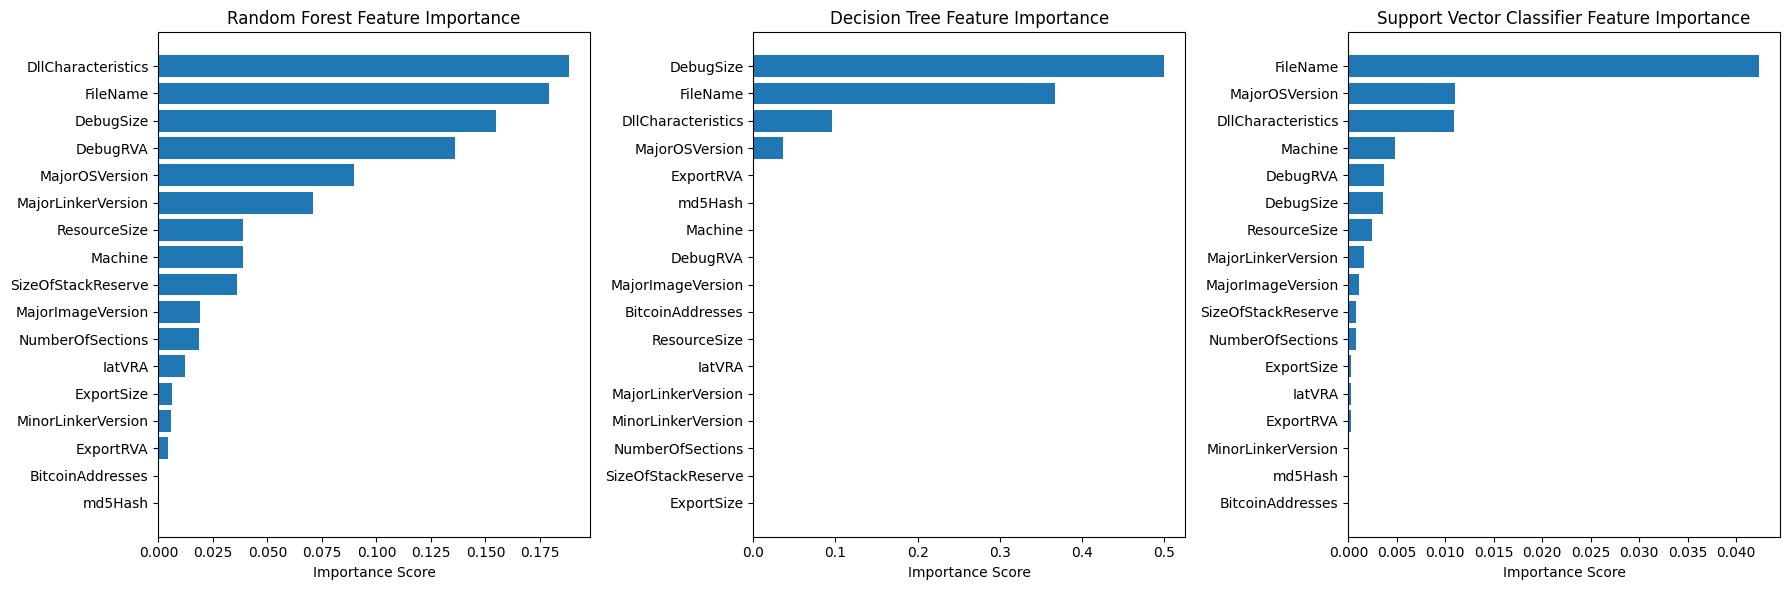

In [21]:
# Gather importances from the models (from the last fold)
from sklearn.inspection import permutation_importance
importances = {}

importances['Random Forest'] = sklearn_models['Random Forest'].feature_importances_
importances['Decision Tree'] = sklearn_models['Decision Tree'].feature_importances_
result = permutation_importance(sklearn_models[model_name], X_test, y_test, n_repeats=5, random_state=42)
importances['Support Vector Classifier'] = result.importances_mean
#importances['Support Vector Classifier'] = sklearn_models['SVC'].feature_importances_

# Create a 1x3 plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
features = X.columns

for i, (model_name, imp) in enumerate(importances.items()):
  # Sort features by importance for a cleaner plot
  sorted_idx = np.argsort(imp)

  ax = axes[i]
  ax.barh(features[sorted_idx], imp[sorted_idx])
  ax.set_title(f"{model_name} Feature Importance")
  ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()